<a href="https://colab.research.google.com/github/10hley-syl20/Data-Science-Portfolio/blob/main/Pronostico_Turistas_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pronostico de turistas por mes y por nacionalidad, 2026

Maestria en Ciencia de Datos e Inteligencia Artificial (UASD).
Tarea 08, Creacion de un modelo de regresion lineal.
Trabajo de Dishley.

La idea es pronosticar cuantos turistas van a entrar por mes en 2026, y
tambien por nacionalidad, usando el historico 2022-2025 de entradas por
pais. Primero sigo los pasos que pide la tarea con un modelo de regresion
lineal (entrenamiento, prueba, metricas, coeficientes, graficos), y
despues agrego un poco mas de analisis para usar el modelo en algo real:
repartir el pronostico entre los 132 paises segun su peso historico.


### Importar las bibliotecas necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro

import warnings
warnings.filterwarnings("ignore")


### Seleccion de los datos

El archivo es `Entradas x Nacionalidad y Año.xlsx`, del Ministerio de
Turismo de Republica Dominicana: una fila por pais y año (2022-2025), con
una columna por mes con la cantidad de turistas que entraron.


In [ ]:
archivo = "Entradas x Nacionalidad y Año.xlsx"
df = pd.read_excel(archivo)
df.head()


,País de nacionalidad,Enero,febrero,marzo,abril,mayo,junio,julio,agosto,septiembre,octubre,noviembre,diciembre,Año
0,Estados Unidos,202772,227778,296709,236364,219579,285931,302256,216662,116446,152260,194456,255808,2025
1,República Dominicana,109053,98721,104188,114127,113186,146402,164378,137510,97125,106634,107716,220170,2025
2,Canadá,138712,132706,139835,101069,44200,28808,34950,30818,21167,36886,96080,127970,2025
3,Argentina,51742,39827,37634,37056,42289,35261,43581,30304,28745,30683,34394,38997,2025
4,Colombia,31566,19849,23493,31056,35236,41123,35264,43424,42076,49163,40246,47426,2025


### Limpieza y preparacion

In [ ]:
meses = ["Enero", "febrero", "marzo", "abril", "mayo", "junio", "julio",
         "agosto", "septiembre", "octubre", "noviembre", "diciembre"]

print(df.isnull().sum())
print("valores negativos:", (df[meses] < 0).sum().sum())
print("años:", sorted(df["Año"].unique()))
print("paises:", df["País de nacionalidad"].nunique())


País de nacionalidad    0
Enero                   0
febrero                 0
marzo                   0
abril                   0
mayo                    0
junio                   0
julio                   0
agosto                  0
septiembre              0
octubre                 0
noviembre               0
diciembre               0
Año                     0
dtype: int64
valores negativos: 0
años: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
paises: 132


No hay nulos ni negativos, asi que no hay que limpiar nada, solo segui adelante. Antes de armar el modelo, un vistazo rapido a como se reparte el turismo por pais.

In [ ]:
df["Total_Anual"] = df[meses].sum(axis=1)
turistas_por_pais = df.groupby("País de nacionalidad")["Total_Anual"].sum().sort_values(ascending=False)
turistas_por_pais.head(15)


País de nacionalidad
Estados Unidos          10051272
República Dominicana     5615463
Canadá                   3360895
Colombia                 1451096
Argentina                1132694
Puerto Rico               878680
Reino Unido               731325
Francia                   686332
España                    618884
Alemania                  557255
Chile                     532968
Brasil                    501173
México                    485534
Perú                      432403
Cuba                      391935
Name: Total_Anual, dtype: int64

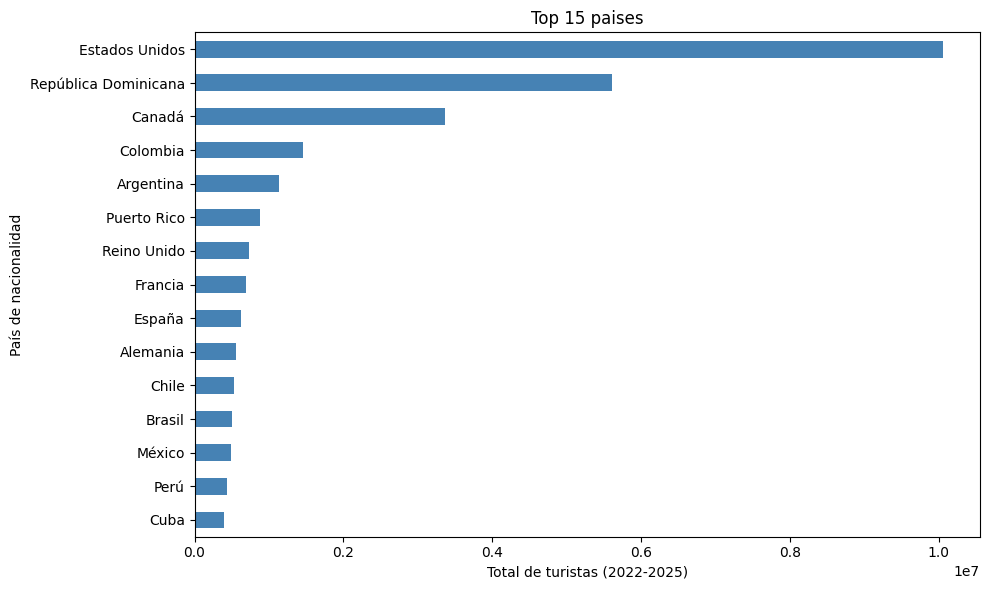

In [ ]:
plt.figure(figsize=(10, 6))
turistas_por_pais.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Total de turistas (2022-2025)")
plt.title("Top 15 paises")
plt.tight_layout()
plt.show()


In [ ]:
total_general = turistas_por_pais.sum()
top5 = turistas_por_pais.head(5)
for pais, total in top5.items():
    print(f"{pais}: {total:,.0f} ({total / total_general:.1%})")
print(f"los 5 primeros son el {top5.sum() / total_general:.1%} del total")


Estados Unidos: 10,051,272 (30.8%)
República Dominicana: 5,615,463 (17.2%)
Canadá: 3,360,895 (10.3%)
Colombia: 1,451,096 (4.4%)
Argentina: 1,132,694 (3.5%)
los 5 primeros son el 66.3% del total


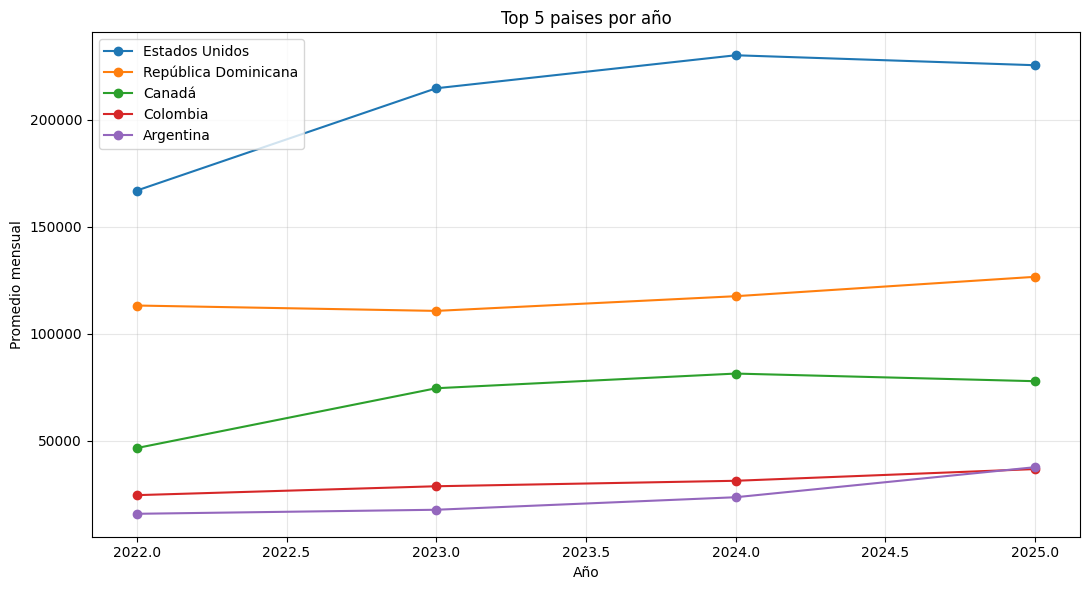

In [ ]:
top5_paises = top5.index.tolist()
df_top5 = df[df["País de nacionalidad"].isin(top5_paises)]

plt.figure(figsize=(11, 6))
for pais in top5_paises:
    datos_pais = df_top5[df_top5["País de nacionalidad"] == pais].sort_values("Año")
    promedio = datos_pais.set_index("Año")[meses].mean(axis=1)
    plt.plot(promedio.index, promedio.values, marker="o", label=pais)
plt.xlabel("Año"); plt.ylabel("Promedio mensual")
plt.title("Top 5 paises por año")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Canada y Francia son bastante mas estacionales que Estados Unidos o
Republica Dominicana, cada pais tiene su propio patron. Eso me sirve mas
adelante para repartir el pronostico total entre paises.

Reviso tambien si todos los paises tienen los 4 años de historia.


In [ ]:
mes_numero = {mes: i + 1 for i, mes in enumerate(meses)}

largo = df.melt(id_vars=["País de nacionalidad", "Año"], value_vars=meses,
                 var_name="Mes_nombre", value_name="Turistas")
largo["Mes"] = largo["Mes_nombre"].map(mes_numero)
largo["Fecha"] = pd.to_datetime(dict(year=largo["Año"], month=largo["Mes"], day=1))

fechas_unicas = sorted(largo["Fecha"].unique())
t_por_fecha = {f: i + 1 for i, f in enumerate(fechas_unicas)}
largo["t"] = largo["Fecha"].map(t_por_fecha)
largo = largo.sort_values(["País de nacionalidad", "Fecha"]).reset_index(drop=True)

años_por_pais = df.groupby("País de nacionalidad")["Año"].apply(lambda s: sorted(s.unique()))
incompletos = años_por_pais[años_por_pais.apply(len) < 4]
print(f"{len(incompletos)} de {len(años_por_pais)} paises no tienen los 4 años completos, por ejemplo:")
print(incompletos.head(5))


12 de 132 paises no tienen los 4 años completos, por ejemplo:
País de nacionalidad
Angola              [2022, 2024]
Belice              [2023, 2025]
Camboya             [2022, 2023]
Kirguistán          [2022, 2024]
Kuwait        [2022, 2023, 2024]
Name: Año, dtype: object


Con 12 paises sin historia completa (por ejemplo Santa Lucia solo aparece
en 2025), no tiene mucho sentido un modelo separado por pais. Por eso el
modelo de regresion se hace sobre el total nacional, y el reparto por
pais se hace despues con la participacion historica de cada uno.


In [ ]:
serie_total = largo.groupby(["Fecha", "Año", "Mes"])["Turistas"].sum().reset_index().sort_values("Fecha")
serie_total["t"] = np.arange(1, len(serie_total) + 1)
mes_dum = pd.get_dummies(serie_total["Mes"], prefix="Mes", drop_first=True).astype(int)
X = pd.concat([serie_total[["t"]], mes_dum], axis=1)
y = serie_total["Turistas"]

print(len(serie_total), "meses, de", serie_total["Fecha"].min().date(), "a", serie_total["Fecha"].max().date())
X.head()


48 meses, de 2022-01-01 a 2025-12-01


,t,Mes_2,Mes_3,Mes_4,Mes_5,Mes_6,Mes_7,Mes_8,Mes_9,Mes_10,Mes_11,Mes_12
0,1,0,0,0,0,0,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0,0,0,0,0
2,3,0,1,0,0,0,0,0,0,0,0,0
3,4,0,0,1,0,0,0,0,0,0,0,0
4,5,0,0,0,1,0,0,0,0,0,0,0


### Reasignacion de la variable explicativa (X) y la variable respuesta (Y)

X es el tiempo (t, del 1 al 48) mas las dummies de mes, que capturan la
estacionalidad (enero queda como base). Y es la cantidad de turistas por
mes. Eso es lo que se le pide al modelo que aprenda: turistas = b0 + b1*t
+ suma de b_mes * dummy_mes.


### Dividimos los datos en conjuntos de entrenamiento y prueba

Uso 2022-2024 para entrenar y 2025 (ya conocido) para probar. No uso
`train_test_split` con mezcla al azar porque esto es una serie de tiempo,
si mezclo los meses el modelo terminaria entrenando con datos "del
futuro" respecto a los que se supone que prueba.


In [ ]:
train = serie_total["Año"] < 2025
test = serie_total["Año"] == 2025

X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

print(len(X_train), "meses de entrenamiento (2022-2024) y", len(X_test), "meses de prueba (2025)")


36 meses de entrenamiento (2022-2024) y 12 meses de prueba (2025)


### Seleccion del modelo e instanciado

In [ ]:
modelo = LinearRegression()


### Entrenamiento del modelo

In [ ]:
modelo.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediccion con los datos de prueba

In [ ]:
y_pred_test = modelo.predict(X_test)

pd.DataFrame({"Fecha": serie_total.loc[test, "Fecha"].values,
              "Real": y_test.values,
              "Prediccion": y_pred_test.round(0)})


,Fecha,Real,Prediccion
0,2025-01-01,759928,763672.0
1,2025-02-01,740657,775416.0
2,2025-03-01,819979,845883.0
3,2025-04-01,749268,784964.0
4,2025-05-01,673743,734490.0
5,2025-06-01,770517,818030.0
6,2025-07-01,863785,894121.0
7,2025-08-01,707175,768451.0
8,2025-09-01,490431,573654.0
9,2025-10-01,593022,640033.0


### Metricas de evaluacion

In [ ]:
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
wape_test = np.abs(y_test.values - y_pred_test).sum() / np.abs(y_test.values).sum()

print("R2:", round(r2, 3))
print("MAE:", round(mae, 1))
print("RMSE:", round(rmse, 1))
print("WAPE:", f"{wape_test:.1%}")


R2: 0.858
MAE: 39732.3
RMSE: 44731.6
WAPE: 5.4%


### Coeficientes del modelo

In [ ]:
print("intercepto:", round(modelo.intercept_, 1))
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f"  {nombre}: {round(coef, 1)}")


intercepto: 587366.8
  t: 4765.0
  Mes_2: 6978.3
  Mes_3: 72680.6
  Mes_4: 6996.6
  Mes_5: -48242.7
  Mes_6: 30532.6
  Mes_7: 101858.9
  Mes_8: -28576.8
  Mes_9: -228138.4
  Mes_10: -166524.8
  Mes_11: -72008.5
  Mes_12: 137483.5


### Graficar los datos de entrenamiento y prueba junto con la linea de regresion

Como hay mas de una variable explicativa (t y los meses), la "linea" de
regresion es en realidad una curva ajustada en el tiempo, no una recta
simple.


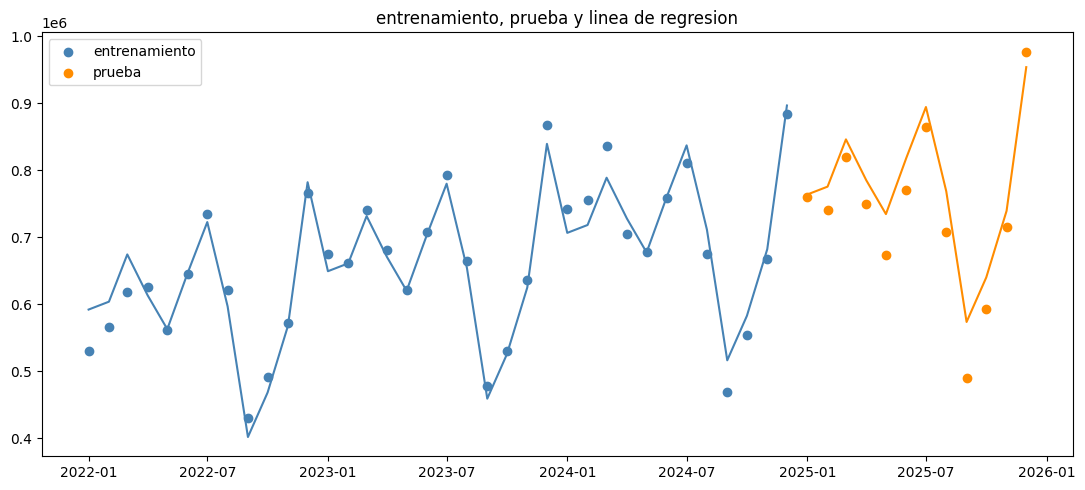

In [ ]:
pred_train = modelo.predict(X_train)

plt.figure(figsize=(11, 5))
plt.scatter(serie_total.loc[train, "Fecha"], y_train, color="steelblue", label="entrenamiento")
plt.scatter(serie_total.loc[test, "Fecha"], y_test, color="darkorange", label="prueba")
plt.plot(serie_total.loc[train, "Fecha"], pred_train, color="steelblue")
plt.plot(serie_total.loc[test, "Fecha"], y_pred_test, color="darkorange")
plt.title("entrenamiento, prueba y linea de regresion")
plt.legend()
plt.tight_layout()
plt.show()


Ya probe el modelo contra datos que no vio. Ahora lo reentreno con todo
el historico (2022-2025) para usarlo en el pronostico real de 2026.


In [ ]:
modelo = LinearRegression().fit(X, y)
print("R2 con todo el historico:", round(r2_score(y, modelo.predict(X)), 3))

X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(y, X_sm).fit()
modelo_sm.summary()


R2 con todo el historico: 0.947


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Turistas   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     52.40
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           9.97e-19
Time:                        12:56:10   Log-Likelihood:                -558.18
No. Observations:                  48   AIC:                             1142.
Df Residuals:                      35   BIC:                             1167.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.035e+05   1.72e+04     35.111      0.000    5.69e+05    6.38e+05
t           3868.2944    342.314     11.300      0.000    3173.360    4563.229
Mes_2        121.4556   2.25e+04      0.005      0.996   -4.56e+04    4.58e+04
Mes_3       6.893e+04   2.25e+04      3.062      0.004    2.32e+04    1.15e+05
Mes_4       1698.8667   2.25e+04      0.075      0.940    -4.4e+04    4.74e+04
Mes_5      -5.891e+04   2.25e+04     -2.613      0.013   -1.05e+05   -1.31e+04
Mes_6       2.407e+04   2.26e+04      1.067      0.293   -2.17e+04    6.99e+04
Mes_7       1.006e+05   2.26e+04      4.452      0.000    5.47e+04    1.46e+05
Mes_8      -3.668e+04   2.26e+04     -1.621      0.114   -8.26e+04    9251.482
Mes_9      -2.408e+05   2.27e+04    -10.626      0.000   -2.87e+05   -1.95e+05
Mes_10     -1.693e+05   2.27e+04     -7.454      0.000   -2.15e+05   -1.23e+05
Mes_11     -6.795e+04   2.28e+04     -2.986      0.005   -1.14e+05   -2.18e+04
Mes_12      1.541e+05   2.28e+04      6.754      0.000    1.08e+05       2e+05
==============================================================================
Omnibus:                        3.676   Durbin-Watson:                   0.741
Prob(Omnibus):                  0.159   Jarque-Bera (JB):                2.565
Skew:                          -0.476   Prob(JB):                        0.277
Kurtosis:                       3.613   Cond. No.                         352.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Graficar los datos y la linea de regresion

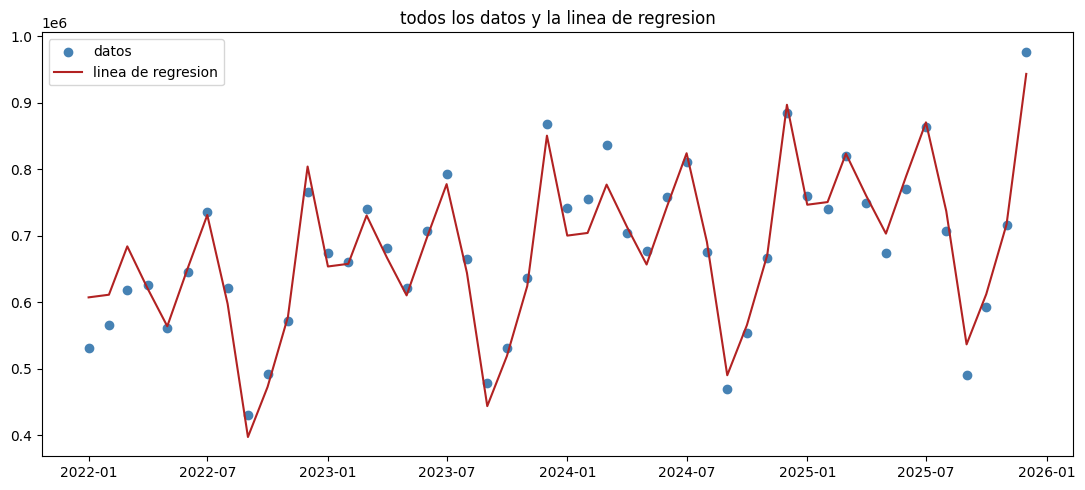

In [ ]:
plt.figure(figsize=(11, 5))
plt.scatter(serie_total["Fecha"], y, color="steelblue", label="datos")
plt.plot(serie_total["Fecha"], modelo.predict(X), color="firebrick", label="linea de regresion")
plt.title("todos los datos y la linea de regresion")
plt.legend()
plt.tight_layout()
plt.show()


Con esto ya esta lo que pedia la tarea. Lo que sigue es extra, lo hice
para no quedarme solo con un R2 alto sin revisar nada mas: comparacion
contra algo mas simple, los supuestos de la regresion, y el pronostico
real por pais para 2026.


Comparo el modelo contra algo bien simple: usar el mismo mes del año
anterior como pronostico (naive estacional). Si el modelo no le gana ni a
eso, no vale mucho la pena usarlo.


In [ ]:
def wape(real, pred):
    real = np.asarray(real, float); pred = np.asarray(pred, float)
    return np.abs(real - pred).sum() / np.abs(real).sum()

serie_total["Naive_12"] = serie_total["Turistas"].shift(12)

for anio_prueba in [2024, 2025]:
    tr = (serie_total["Año"] < anio_prueba).values
    te = (serie_total["Año"] == anio_prueba).values
    m = LinearRegression().fit(X[tr], y[tr])
    pred = m.predict(X[te])
    naive = serie_total.loc[te, "Naive_12"].values
    real = y[te].values
    print(f"{anio_prueba}: regresion wape={wape(real, pred):.1%}   naive wape={wape(real, naive):.1%}")


2024: regresion wape=7.3%   naive wape=5.8%
2025: regresion wape=5.4%   naive wape=4.5%


El naive queda parecido o mejor que la regresion en los dos años. Eso no
significa que el modelo este mal, pero si que hay que tomar el R2 alto
con cuidado, ajustar bien el historico no es lo mismo que predecir bien
el futuro. Sigo usando la regresion porque el objetivo de la tarea es
aplicar regresion lineal con tendencia y estacionalidad, y porque el
naive no sirve para repartir el pronostico entre paises.

Ahora los supuestos de la regresion sobre el modelo ajustado con todo el
historico. Ademas de los 5 basicos (linealidad, independencia,
homocedasticidad, normalidad, no multicolinealidad) agrego la distancia
de Cook para ver si algun mes pesa demasiado en el ajuste.


In [ ]:
residuos = modelo_sm.resid
ajustados = modelo_sm.fittedvalues

reset = linear_reset(modelo_sm, power=2, use_f=True)
print("reset (forma funcional) p =", round(reset.pvalue, 4))

dw = durbin_watson(residuos)
print("durbin-watson:", round(dw, 3))
print(acorr_ljungbox(residuos, lags=[1, 6, 12], return_df=True))

_, p_bp, _, _ = het_breuschpagan(residuos, X_sm)
print("breusch-pagan p =", round(p_bp, 3))

_, p_sh = shapiro(residuos)
print("shapiro-wilk p =", round(p_sh, 3))

print("vif:")
for i, nombre in enumerate(X.columns):
    print(f"  {nombre}: {round(variance_inflation_factor(X.values, i), 2)}")


reset (forma funcional) p = 0.0427
durbin-watson: 0.741
      lb_stat  lb_pvalue
1   14.414479   0.000147
6   24.316039   0.000457
12  27.288055   0.007022
breusch-pagan p = 0.123
shapiro-wilk p = 0.408
vif:
  t: 1.07
  Mes_2: 1.83
  Mes_3: 1.84
  Mes_4: 1.84
  Mes_5: 1.84
  Mes_6: 1.84
  Mes_7: 1.85
  Mes_8: 1.85
  Mes_9: 1.86
  Mes_10: 1.87
  Mes_11: 1.88
  Mes_12: 1.88


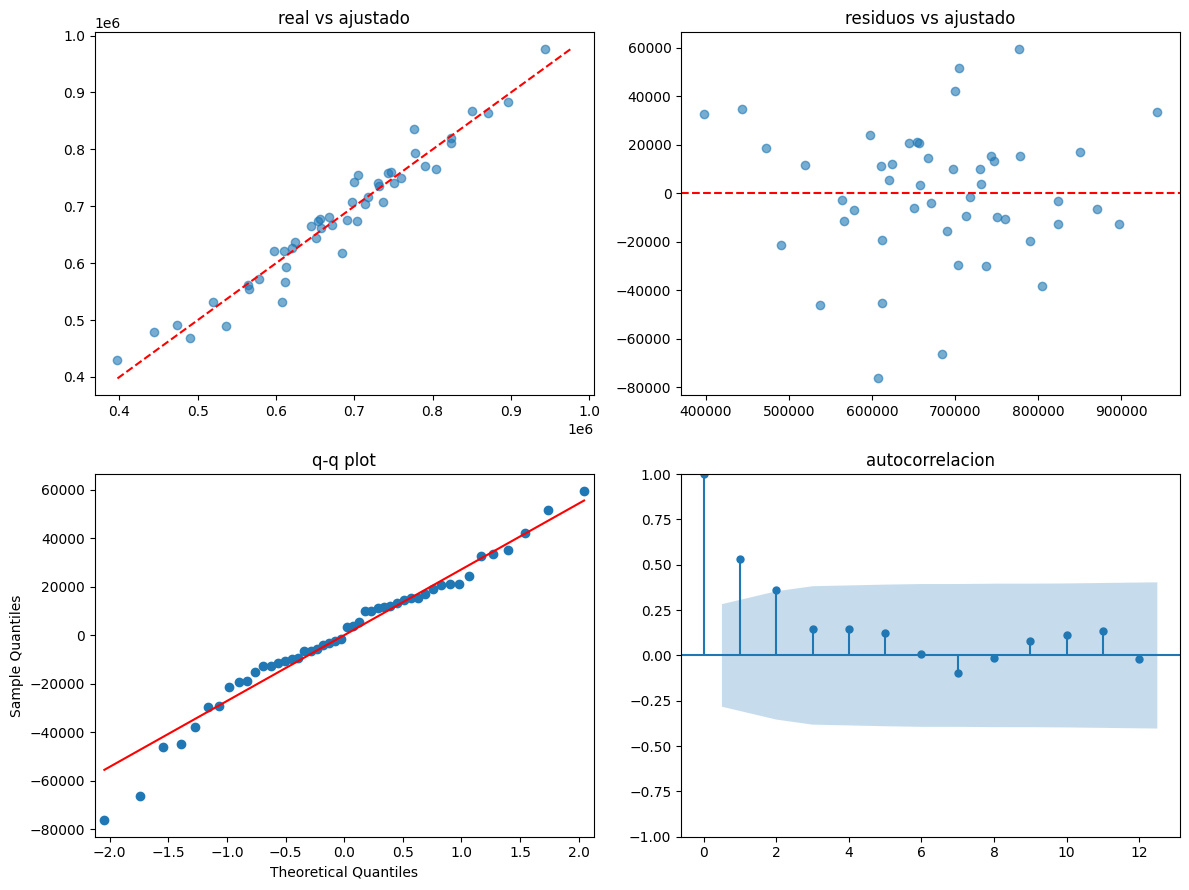

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(ajustados, y, alpha=0.6)
lims = [min(ajustados.min(), y.min()), max(ajustados.max(), y.max())]
axes[0, 0].plot(lims, lims, "r--")
axes[0, 0].set_title("real vs ajustado")

axes[0, 1].scatter(ajustados, residuos, alpha=0.6)
axes[0, 1].axhline(0, color="r", linestyle="--")
axes[0, 1].set_title("residuos vs ajustado")

qqplot(residuos, line="s", ax=axes[1, 0])
axes[1, 0].set_title("q-q plot")

plot_acf(residuos, ax=axes[1, 1], lags=12)
axes[1, 1].set_title("autocorrelacion")

plt.tight_layout()
plt.show()


In [ ]:
cooks_d = modelo_sm.get_influence().cooks_distance[0]
umbral = 4 / len(serie_total)
cook_df = serie_total[["Fecha", "Turistas"]].copy()
cook_df["Cook_D"] = cooks_d
cook_df.sort_values("Cook_D", ascending=False).head(8)


,Fecha,Turistas,Cook_D
0,2022-01-01,530957,0.251026
2,2022-03-01,617756,0.188866
26,2024-03-01,836502,0.123546
25,2024-02-01,755832,0.092672
44,2025-09-01,490431,0.092147
1,2022-02-01,566235,0.087488
11,2022-12-01,765935,0.062238
24,2024-01-01,742229,0.061394


El durbin-watson y el ljung-box salen mal (hay autocorrelacion en los
residuos), asi que los errores estandar normales de la regresion no son
del todo confiables. Los recalculo con la correccion HAC, que es lo que
se usa normalmente cuando hay autocorrelacion, los coeficientes no
cambian pero si el error estandar y el p-valor.


In [ ]:
modelo_hac = sm.OLS(y, X_sm).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
pd.DataFrame({"coef": modelo_sm.params, "ee_ols": modelo_sm.bse, "p_ols": modelo_sm.pvalues,
              "ee_hac": modelo_hac.bse, "p_hac": modelo_hac.pvalues})


,coef,ee_ols,p_ols,ee_hac,p_hac
const,603468.405556,17187.430218,7.086735e-29,28785.800836,1.395350e-97
t,3868.294444,342.313893,3.148914e-13,441.423126,1.897261e-18
Mes_2,121.455556,22501.768807,9.957240e-01,12733.708205,9.923898e-01
Mes_3,68934.161111,22509.578757,4.203464e-03,13886.172218,6.897395e-07
Mes_4,1698.866667,22522.589323,9.403025e-01,23176.822885,9.415672e-01
Mes_5,-58906.427778,22540.791500,1.312859e-02,20560.029939,4.168849e-03
Mes_6,24074.027778,22564.172722,2.933151e-01,19455.586527,2.159446e-01
Mes_7,100591.233333,22592.716912,8.282560e-05,21617.805904,3.268773e-06
Mes_8,-36682.561111,22626.404528,1.139445e-01,24228.684823,1.300224e-01
Mes_9,-240834.355556,22665.212637,1.691629e-12,26048.512724,2.339055e-20


Ahora el pronostico de 2026, con intervalo de prediccion del 95% para el total, y despues repartido por pais usando la participacion historica de cada uno en cada mes.

In [ ]:
participacion = largo.groupby(["País de nacionalidad", "Mes"])["Turistas"].sum() / largo.groupby("Mes")["Turistas"].sum()

futuro = pd.DataFrame({"Mes": np.arange(1, 13)})
futuro["t"] = np.arange(49, 61)
dummies_futuro = pd.get_dummies(futuro["Mes"], prefix="Mes").astype(int)
for col in mes_dum.columns:
    if col not in dummies_futuro.columns:
        dummies_futuro[col] = 0
dummies_futuro = dummies_futuro[mes_dum.columns]
X_futuro = pd.concat([futuro[["t"]], dummies_futuro], axis=1)[X.columns]

pronostico_total = np.clip(modelo.predict(X_futuro), 0, None)
tope = serie_total.groupby("Mes")["Turistas"].max() * 2
for i, mes in enumerate(futuro["Mes"]):
    pronostico_total[i] = min(pronostico_total[i], tope.loc[mes])

X_futuro_sm = sm.add_constant(X_futuro, has_constant="add")[X_sm.columns]
intervalo = modelo_sm.get_prediction(X_futuro_sm).summary_frame(alpha=0.05)

tabla_total = pd.DataFrame({"Mes": futuro["Mes"], "Pronostico": pronostico_total.round(0).astype(int),
                             "PI_inf": intervalo["obs_ci_lower"].round(0).astype(int),
                             "PI_sup": intervalo["obs_ci_upper"].round(0).astype(int)})
tabla_total


,Mes,Pronostico,PI_inf,PI_sup
0,1,793015,717846,868183
1,2,797005,721836,872173
2,3,869686,794517,944854
3,4,806319,731150,881487
4,5,749582,674413,824750
5,6,836430,761262,911599
6,7,916816,841647,991984
7,8,783410,708242,858579
8,9,583127,507958,658295
9,10,658559,583390,733727


In [ ]:
filas = []
for pais in largo["País de nacionalidad"].unique():
    for i, mes in enumerate(futuro["Mes"]):
        p = participacion.get((pais, mes), np.nan)
        if pd.isna(p):
            continue
        filas.append({"País de nacionalidad": pais, "Mes": mes,
                       "Turistas_2026": pronostico_total[i] * p})

pronostico_pais = pd.DataFrame(filas)
pronostico_pais["Turistas_2026"] = pronostico_pais["Turistas_2026"].round(0).astype(int)

chequeo = pronostico_pais.groupby("Mes")["Turistas_2026"].sum()
print(pd.DataFrame({"suma_paises": chequeo, "total": pronostico_total.round(0).astype(int)}))


     suma_paises   total
Mes                     
1         793015  793015
2         797002  797005
3         869691  869686
4         806319  806319
5         749582  749582
6         836426  836430
7         916818  916816
8         783414  783410
9         583124  583127
10        658556  658559
11        763742  763743
12        989645  989645


In [ ]:
top10 = pronostico_pais.groupby("País de nacionalidad")["Turistas_2026"].sum().sort_values(ascending=False).head(10).index
tabla_top10 = pronostico_pais[pronostico_pais["País de nacionalidad"].isin(top10)]
tabla_top10.pivot(index="País de nacionalidad", columns="Mes", values="Turistas_2026").loc[top10]


Mes,1,2,3,4,5,6,7,8,9,10,11,12
País de nacionalidad,,,,,,,,,,,,
Estados Unidos,208895,243115,307582,259852,252988,314568,322710,244394,145991,173260,205196,259766
República Dominicana,119712,110858,119128,121814,128508,155252,170334,143993,113907,117132,118210,223967
Canadá,127257,127923,139113,108425,51123,34357,42733,39983,28689,46711,103100,131234
Colombia,31580,20103,25324,29642,34245,39864,34056,40414,41904,46826,39474,43338
Argentina,33360,26956,25078,26426,31400,26808,30997,24031,25081,25980,28099,28114
Puerto Rico,10299,11821,13835,16339,24196,38325,41912,23114,17497,20979,20028,18992
Reino Unido,14580,14777,16177,16548,20698,19081,20879,21249,18736,18409,16989,16686
Francia,23685,30911,21496,22383,11333,7208,13471,15994,7033,13735,14186,19269
España,11760,11145,12229,13327,10162,15254,22347,25305,14307,13416,13375,18689


El modelo no tiene una regresion separada por pais (eso fue lo que se descarto por overfitting), pero cada pais si tiene su propia ecuacion, porque su pronostico es la ecuacion nacional multiplicada por su participacion en ese mes. Como esa participacion depende del mes, hay 12 ecuaciones por pais, una por cada mes del año (una recta simple en t para cada una).

In [ ]:
def coeficientes_mes():
    coef_t = modelo.coef_[0]
    coefs_mes = {1: 0.0}
    for nombre, coef in zip(X.columns[1:], modelo.coef_[1:]):
        mes_num = int(nombre.split("_")[1])
        coefs_mes[mes_num] = coef
    return coef_t, coefs_mes

def imprimir_ecuacion(pais):
    coef_t, coefs_mes = coeficientes_mes()
    print(f"ecuaciones de {pais} (turistas = A + B*t, una por mes):")
    for mes in range(1, 13):
        p = participacion.get((pais, mes), None)
        if p is None:
            continue
        A = p * (modelo.intercept_ + coefs_mes[mes])
        B = p * coef_t
        print(f"  mes {mes:>2}: turistas = {A:,.1f} + {B:,.2f}*t   (participacion {p:.2%})")

imprimir_ecuacion("Canadá")
print()
imprimir_ecuacion("República Dominicana")

# chequeo: para enero 2026 (t=49) la ecuacion debe dar lo mismo que el pronostico ya calculado
pais_chequeo = "Canadá"
coef_t, coefs_mes = coeficientes_mes()
p_check = participacion.get((pais_chequeo, 1))
valor_ecuacion = p_check * (modelo.intercept_ + coefs_mes[1] + coef_t * 49)
valor_tabla = pronostico_pais[(pronostico_pais["País de nacionalidad"] == pais_chequeo) & (pronostico_pais["Mes"] == 1)]["Turistas_2026"].values[0]
print()
print(f"chequeo enero 2026 {pais_chequeo}: ecuacion={valor_ecuacion:,.0f}   tabla ya calculada={valor_tabla:,.0f}")


ecuaciones de Canadá (turistas = A + B*t, una por mes):
  mes  1: turistas = 96,839.9 + 620.75*t   (participacion 16.05%)
  mes  2: turistas = 96,879.4 + 620.88*t   (participacion 16.05%)
  mes  3: turistas = 107,556.0 + 618.76*t   (participacion 16.00%)
  mes  4: turistas = 81,376.3 + 520.17*t   (participacion 13.45%)
  mes  5: turistas = 37,140.5 + 263.83*t   (participacion 6.82%)
  mes  6: turistas = 25,777.0 + 158.89*t   (participacion 4.11%)
  mes  7: turistas = 32,816.4 + 180.30*t   (participacion 4.66%)
  mes  8: turistas = 28,927.4 + 197.43*t   (participacion 5.10%)
  mes  9: turistas = 17,841.0 + 190.31*t   (participacion 4.92%)
  mes 10: turistas = 30,797.5 + 274.38*t   (participacion 7.09%)
  mes 11: turistas = 72,290.4 + 522.19*t   (participacion 13.50%)
  mes 12: turistas = 100,456.5 + 512.97*t   (participacion 13.26%)

ecuaciones de República Dominicana (turistas = A + B*t, una por mes):
  mes  1: turistas = 91,098.2 + 583.95*t   (participacion 15.10%)
  mes  2: turistas 

In [ ]:
pronostico_pais.to_csv("pronostico_2026_por_pais_y_mes.csv", index=False)
print(len(pronostico_pais), "filas guardadas en pronostico_2026_por_pais_y_mes.csv")


1584 filas guardadas en pronostico_2026_por_pais_y_mes.csv


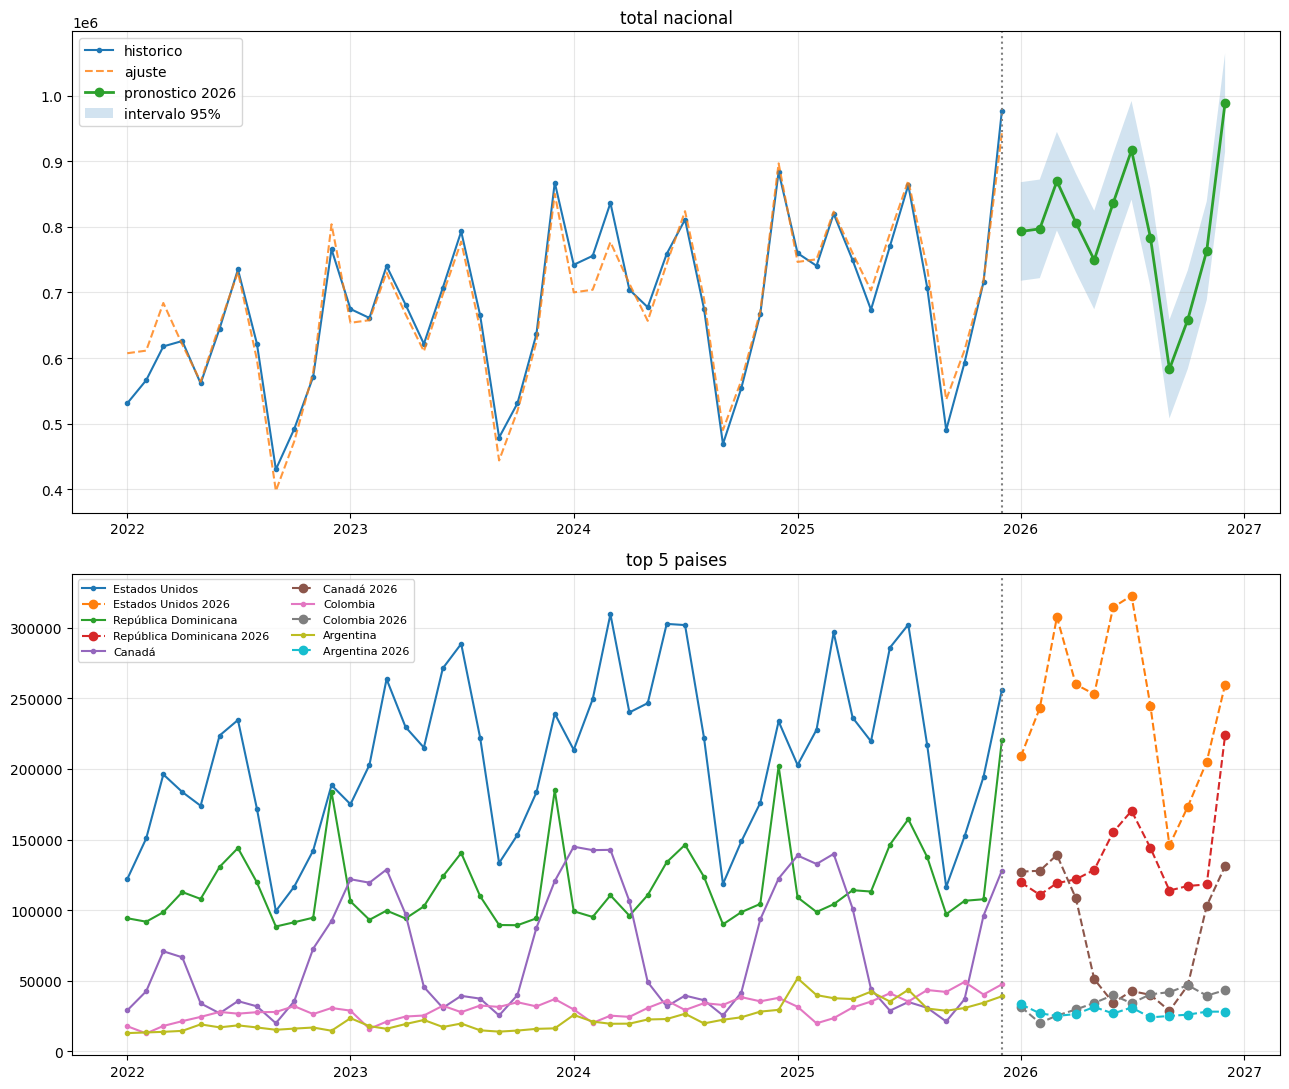

In [ ]:
fechas_2026 = pd.to_datetime([f"2026-{m:02d}-01" for m in futuro["Mes"]])

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

axes[0].plot(serie_total["Fecha"], serie_total["Turistas"], marker="o", markersize=3, label="historico")
axes[0].plot(serie_total["Fecha"], modelo.predict(X), linestyle="--", alpha=0.8, label="ajuste")
axes[0].plot(fechas_2026, pronostico_total, marker="o", linewidth=2, label="pronostico 2026")
axes[0].fill_between(fechas_2026, tabla_total["PI_inf"], tabla_total["PI_sup"], alpha=0.2, label="intervalo 95%")
axes[0].axvline(serie_total["Fecha"].iloc[-1], color="gray", linestyle=":")
axes[0].set_title("total nacional")
axes[0].legend(); axes[0].grid(alpha=0.3)

for pais in top5_paises:
    hist = largo[largo["País de nacionalidad"] == pais].sort_values("Fecha")
    pred = pronostico_pais[pronostico_pais["País de nacionalidad"] == pais].sort_values("Mes")
    axes[1].plot(hist["Fecha"], hist["Turistas"], marker="o", markersize=3, label=f"{pais}")
    axes[1].plot(fechas_2026, pred["Turistas_2026"], marker="o", linestyle="--", label=f"{pais} 2026")
axes[1].axvline(serie_total["Fecha"].iloc[-1], color="gray", linestyle=":")
axes[1].set_title("top 5 paises")
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


En resumen: siguiendo los pasos de la tarea, el modelo entrenado con
2022-2024 y probado contra 2025 da un R2 de prueba razonable pero no le
gana con claridad a un pronostico naive, y hay autocorrelacion en los
residuos (por eso los errores HAC). Aun asi lo uso como modelo principal
porque permite repartir el pronostico entre los 132 paises segun su peso
historico, cosa que un naive no puede hacer. El pronostico de 2026 sigue
el mismo patron estacional del historico, y el intervalo de prediccion
hay que leerlo con cuidado por la autocorrelacion mencionada.
